# 🛡️ Guardrails — Langchan Middleware

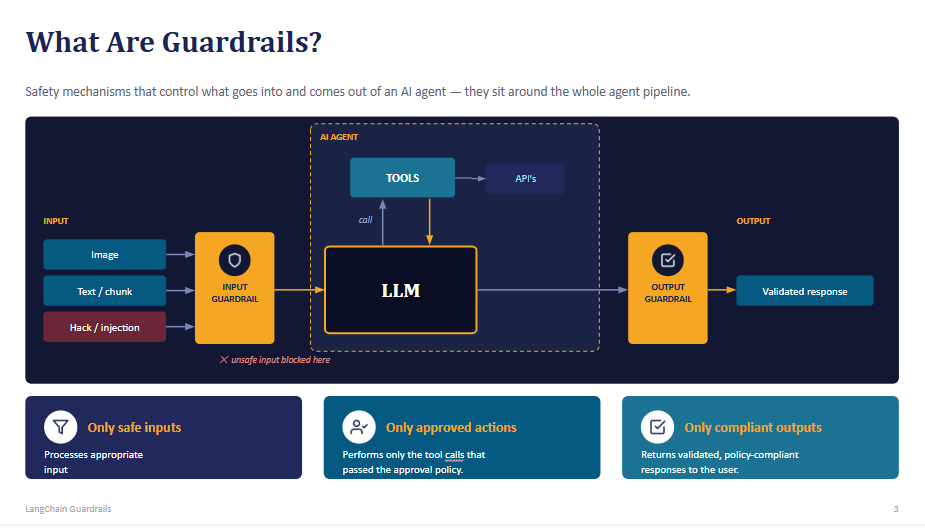


### 📚 Topics Covered
1. Two approaches: Deterministic vs Model-based
2. Built-in: PII - Personally Identifiable Information (PII) Detection Middleware
3. Built-in: Human-in-the-Loop Middleware
4. Custom: Before-Agent Guardrail (input filtering)
5. Custom: After-Agent Guardrail (output safety)
6. Layered / Combined Guardrails
7. Use Case: Healthcare Chatbot

---
> 📌 **Docs Reference:** https://docs.langchain.com/oss/python/langchain/guardrails
https://reference.langchain.com/python/langchain/agents/middleware/types/AgentMidd

---
## ⚖️ Section 2: Two Approaches to Guardrails



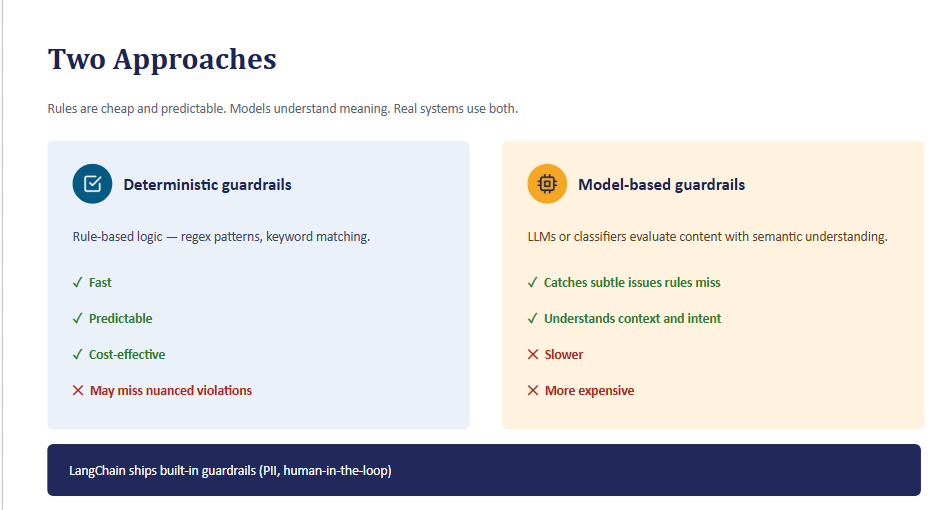

## Deterministic Guardrails

In [ ]:
# Quick illustration of the two approaches

import re

# --- Deterministic approach ---
def deterministic_guardrail(text: str) -> bool:
    """Returns True if content is blocked."""
    banned_keywords = ["hack", "exploit", "malware", "bomb"]
    return any(kw in text.lower() for kw in banned_keywords)

test_inputs = [
    "How do I hack into a database?",
    "What is the capital of France?",
    "Explain how malware spreads",
]

print("=== Deterministic Guardrail Demo ===")
for inp in test_inputs:
    blocked = deterministic_guardrail(inp)
    status = "🚫 BLOCKED" if blocked else "✅ ALLOWED"
    print(f"{status}: {inp}")

=== Deterministic Guardrail Demo ===
🚫 BLOCKED: How do I hack into a database?
✅ ALLOWED: What is the capital of France?
🚫 BLOCKED: Explain how malware spreads


## Model-Based Guardrails

In [2]:
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
from langchain_openai import ChatOpenAI

model = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0,
)

c:\Users\kerol\miniconda3\envs\llmops\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# --- Model-based approach ---
def model_based_guardrail(text: str) -> str:
    """Uses an LLM to evaluate content safety. Returns SAFE or UNSAFE."""

    prompt = f"""Is the following user input safe to process?
Reply with only 'SAFE' or 'UNSAFE'.

Input: {text}"""
    result = model.invoke([{"role": "user", "content": prompt}])
    return result.content.strip()

print("=== Model-Based Guardrail Demo ===")
for inp in test_inputs:
    verdict = model_based_guardrail(inp)
    status = "🚫 UNSAFE" if "UNSAFE" in verdict else "✅ SAFE"
    print(f"{status}: {inp}")

=== Model-Based Guardrail Demo ===
🚫 UNSAFE: How do I hack into a database?
✅ SAFE: What is the capital of France?
✅ SAFE: Explain how malware spreads


---
## 🔒 Section 3: Built-in Guardrail — PII Detection Middleware

LangChain provides built-in `PIIMiddleware` for detecting and handling **Personally Identifiable Information (PII)**.



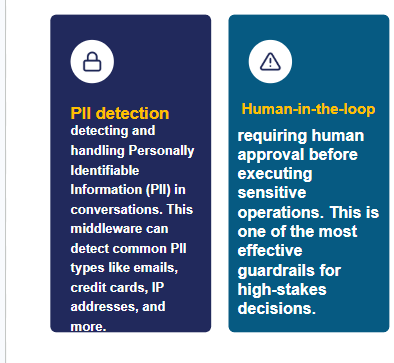

In [5]:
from langchain.agents import create_agent
from langchain.agents.middleware import PIIMiddleware
from langchain_core.tools import tool

In [6]:
# Define a simple dummy tool
@tool
def customer_lookup(query: str) -> str:
    """Look up customer information."""
    return f"Customer record found for query: {query}"


# Create agent with PII Middleware
agent = create_agent(
    model=model,
    tools=[customer_lookup],
    middleware=[
        # Redact emails in user input before sending to model
        PIIMiddleware(
            "email",
            strategy="redact",
            apply_to_input=True,
        ),
        # Mask credit cards in user input
        PIIMiddleware(
            "credit_card",
            strategy="mask",
            apply_to_input=True,
        ),
        # Block API keys - raise error if detected
        PIIMiddleware(
            "api_key",
            detector=r"sk-[a-zA-Z0-9]{32}",
            strategy="block",
            apply_to_input=True,
        ),
    ],
)

print("Agent with PII middleware created successfully!")


Agent with PII middleware created successfully!


In [7]:
# Test PII Redaction
result = agent.invoke({
    "messages": [{
        "role": "user",
        "content": "My email is john.doe@example.com and my card is 5105-1051-0510-5100. Can you help me?"
    }]
})

print("=== Agent Response ===")
print(result["messages"][-1].content)

=== Agent Response ===
I found your customer record associated with your email. How can I assist you further?


In [8]:
result

{'messages': [HumanMessage(content='My email is [REDACTED_EMAIL] and my card is ****-****-****-5100. Can you help me?', additional_kwargs={}, response_metadata={}, id='7e8acd4c-c5d6-4542-8b89-d77e40ce16d4'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 70, 'total_tokens': 90, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_f5dd3ac0b7', 'id': 'chatcmpl-EJxrFNy9JH8NkJWhEw31LOh82TudD', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a0668e-dce8-7172-9c00-8d1e210d974c-0', tool_calls=[{'name': 'customer_lookup', 'args': {'query': '[REDACTED_EMAIL]'}, 'id': 'call_sl2nZZlI3AtAKyeFRudutQlK', 'type': 'tool_call'}]

In [9]:
# Test API Key Blocking
try:
    result = agent.invoke({
        "messages": [{
            "role": "user",
            "content": "Here is my key: sk-abcdefghijklmnopqrstuvwxyz123456"
        }]
    })

except Exception as e:
    print(f"🚫 Blocked as expected: {e}")

🚫 Blocked as expected: Detected 1 instance(s) of api_key in text content


---
## 👤 Section 4: Built-in Guardrail — Human-in-the-Loop Middleware

Pauses agent execution before sensitive operations and waits for human approval.

**Best for:**
- Financial transactions
- Sending emails to external parties
- Deleting production data
- Any operation with significant business impact

**Key requirement:** A `checkpointer` for state persistence across interrupts.

In [10]:
from langchain.agents import create_agent
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.types import Command
from langchain_core.tools import tool

In [11]:
@tool
def search_web(query: str) -> str:
    """Search the web for information."""
    return f"Search results for: {query}"

@tool
def send_email(to: str, subject: str, body: str) -> str:
    """Send an email to a recipient."""
    return f"Email sent to {to} with subject: {subject}"

@tool
def delete_records(table: str, condition: str) -> str:
    """Delete records from the database."""
    return f"Deleted records from {table} where {condition}"



# Create agent with HITL middleware
hitl_agent = create_agent(
    model=model,
    tools=[search_web, send_email, delete_records],
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "send_email": True,       # Require approval
                "delete_records": True,   # Require approval
                "search_web": False,      # Auto-approve
            }
        ),
    ],
    checkpointer=InMemorySaver(),  # Required for state persistence
)

print("Human-in-the-Loop agent created!")

Human-in-the-Loop agent created!


In [ ]:
# Step 1: Invoke — agent will pause before send_email
config = {"configurable": {"thread_id": "session_001"}}

result = hitl_agent.invoke(
    {"messages": [{"role": "user", "content": "Send an email to team@company.com about the Q4 results"}]},
    config=config
)

print("=== Agent paused — awaiting human approval ===")
print(result)

=== Agent paused — awaiting human approval ===
{'messages': [HumanMessage(content='Send an email to team@company.com about the Q4 results', additional_kwargs={}, response_metadata={}, id='85a9f60e-ff12-45db-8e04-7c576ea4cc31'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 71, 'prompt_tokens': 109, 'total_tokens': 180, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_2d78c43f25', 'id': 'chatcmpl-EJxrIaamzRLVazhM6yEHXSdrDoEb4', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a0668e-e4b3-7f10-9514-3fb79111b792-0', tool_calls=[{'name': 'send_email', 'args': {'to': 'team@company.com', 'subject': 'Q4 Results', 'body': 'Dear Team,\n\nI

In [13]:
approved_result = hitl_agent.invoke(
    Command(resume={"decisions": [{"type": "approve"}]}),
    config=config   # Same thread_id resumes the paused session
)

print("=== Approved! Final response ===")
print(approved_result["messages"][-1].content)

=== Approved! Final response ===
The email regarding the Q4 results has been successfully sent to team@company.com.


In [14]:
# Step 3: Alternative — Human REJECTS
config2 = {"configurable": {"thread_id": "session_002"}}

hitl_agent.invoke(
    {"messages": [{"role": "user", "content": "Delete all records from the users table where active=false"}]},
    config=config2
)

print("=== Agent paused — awaiting human approval ===")
print(result)

=== Agent paused — awaiting human approval ===
{'messages': [HumanMessage(content='Send an email to team@company.com about the Q4 results', additional_kwargs={}, response_metadata={}, id='85a9f60e-ff12-45db-8e04-7c576ea4cc31'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 71, 'prompt_tokens': 109, 'total_tokens': 180, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_2d78c43f25', 'id': 'chatcmpl-EJxrIaamzRLVazhM6yEHXSdrDoEb4', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a0668e-e4b3-7f10-9514-3fb79111b792-0', tool_calls=[{'name': 'send_email', 'args': {'to': 'team@company.com', 'subject': 'Q4 Results', 'body': 'Dear Team,\n\nI

In [15]:
rejected_result = hitl_agent.invoke(
    Command(resume={"decisions": [{"type": "reject", "reason": "Too risky, needs DBA review"}]}),
    config=config2
)

print("=== Rejected! Final response ===")
print(rejected_result["messages"][-1].content)

=== Rejected! Final response ===
It seems that I cannot execute the deletion of records from the users table. If you would like to proceed with this action, please confirm, and I will assist you further.


---
## ⚙️ Section 5: Custom Guardrail — Before-Agent Hook (Input Filter)

Use `before_agent()` to validate or block requests **before any LLM processing begins**.

**Best for:**
- Keyword/content filtering
- Authentication checks
- Rate limiting
- Blocking specific categories of requests

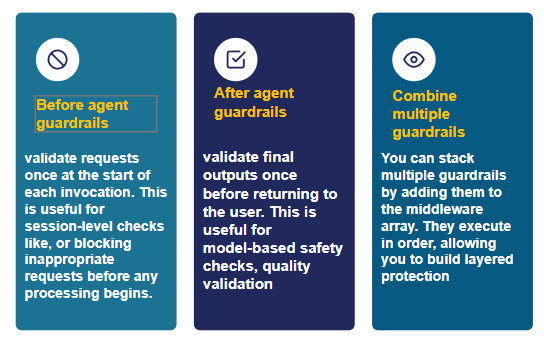

In [16]:
from typing import Any
from langchain.agents.middleware import AgentMiddleware, AgentState, hook_config
from langgraph.runtime import Runtime
from langchain.agents import create_agent
from langchain_core.tools import tool

AgentMiddleware is the base class LangChain gives you for writing custom middleware. Its job is to define the shape — the set of hooks the agent will call, and their signatures.

In [17]:
class ContentFilterMiddleware(AgentMiddleware):
    """
    Deterministic guardrail: Block requests containing banned keywords.
    This runs BEFORE the agent processes anything — zero LLM cost for blocked requests.
    """

    def __init__(self, banned_keywords: list[str]):
        super().__init__()
        self.banned_keywords = [kw.lower() for kw in banned_keywords]

    @hook_config(can_jump_to=["end"])
    def before_agent(self, state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
        if not state["messages"]:
            return None

        first_message = state["messages"][0]
        if first_message.type != "human":
            return None

        content = first_message.content.lower()

        for keyword in self.banned_keywords:
            if keyword in content:
                print(f"🚫 Blocked — keyword detected: '{keyword}'")
                return {
                    "messages": [{
                        "role": "assistant",
                        "content": (
                            "I cannot process requests containing inappropriate content. "
                            "Please rephrase your request."
                        )
                    }],
                    "jump_to": "end"
                }
        return None
    


@tool
def search_tool(query: str) -> str:
    """Search for information."""
    return f"Results for: {query}"



# Create agent with content filter
filtered_agent = create_agent(
    model=model,
    tools=[search_tool],
    middleware=[
        ContentFilterMiddleware(
            banned_keywords=["hack", "exploit", "malware", "jailbreak", "bypass"]
        ),
    ],
)

print("Content filter agent created!")

Content filter agent created!


In [18]:
# Test 1: Safe request — should pass through
result = filtered_agent.invoke({
    "messages": [{"role": "user", "content": "What is machine learning?"}]
})
print("✅ Safe request response:")
print(result["messages"][-1].content)

✅ Safe request response:
Machine learning is a subset of artificial intelligence (AI) that focuses on the development of algorithms and statistical models that enable computers to perform tasks without explicit instructions. Instead of being programmed to perform a specific task, machine learning systems learn from data, identifying patterns and making decisions based on that data.

Key aspects of machine learning include:

1. **Data-Driven**: Machine learning relies on large amounts of data to train models. The more data available, the better the model can learn and make predictions.

2. **Algorithms**: Various algorithms are used in machine learning, including supervised learning (where the model is trained on labeled data), unsupervised learning (where the model identifies patterns in unlabeled data), and reinforcement learning (where the model learns by receiving feedback from its actions).

3. **Applications**: Machine learning is used in various applications, such as image and sp

In [19]:
# Test 2: Unsafe request — should be blocked
result = filtered_agent.invoke({
    "messages": [{"role": "user", "content": "How do I hack into a server?"}]
})
print("🚫 Unsafe request response:")
print(result["messages"][-1].content)

🚫 Blocked — keyword detected: 'hack'
🚫 Unsafe request response:
I cannot process requests containing inappropriate content. Please rephrase your request.


---
## 🔍 Section 6: Custom Guardrail — After-Agent Hook (Output Safety)

Use `after_agent()` to validate the final agent response **before the user sees it**.

**Best for:**
- Model-based safety evaluation of outputs
- Compliance scanning (e.g. legal, medical, financial disclaimers)
- Quality validation
- Removing sensitive info that slipped through

In [20]:
from typing import Any
from langchain.agents.middleware import AgentMiddleware, AgentState, hook_config
from langgraph.runtime import Runtime
from langchain_core.messages import AIMessage
from langchain.agents import create_agent
from langchain_core.tools import tool

In [54]:
class SafetyGuardrailMiddleware(AgentMiddleware):
    """
    Model-based guardrail: Use an LLM to evaluate response safety.
    Runs AFTER the agent produces a response, before it reaches the user.
    """

    def __init__(self):
        super().__init__()
        self.safety_model = model

    @hook_config(can_jump_to=["end"])
    def after_agent(self, state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
        if not state["messages"]:
            return None

        last_message = state["messages"][-1]
        if not isinstance(last_message, AIMessage):
            return None

        # Use a lightweight model as the safety judge
        safety_prompt = f"""Reply with only 'SAFE' or 'UNSAFE'.
Mark UNSAFE if the response mentions any competitor product by name.

Response to evaluate:
{last_message.content}"""

        result = self.safety_model.invoke([{"role": "user", "content": safety_prompt}])

        if "UNSAFE" in result.content.upper():
            print("⚠️  Output flagged as UNSAFE ")
            last_message.content = (
                "I'm unable to provide that response. "
               
            )

        return None
    




@tool
def general_tool(query: str) -> str:
    """A general purpose tool."""
    return f"Tool result: {query}"


safe_agent = create_agent(
    model=model,
    tools=[general_tool],
    middleware=[SafetyGuardrailMiddleware()],
)

print("Output safety agent created!")



Output safety agent created!


In [58]:
# Test output safety check
result = safe_agent.invoke({
    "messages": [{"role": "user", "content": "What is cloud?"}]
})
print("Response:")
print(result["messages"][-1].content)

Response:
Cloud computing is a technology that allows users to access and store data and applications on remote servers instead of on local computers or servers. It enables on-demand access to a shared pool of configurable computing resources, such as networks, servers, storage, applications, and services, which can be rapidly provisioned and released with minimal management effort.

Key characteristics of cloud computing include:

1. **On-Demand Self-Service**: Users can automatically provision computing resources as needed without requiring human interaction with service providers.

2. **Broad Network Access**: Services are available over the network and can be accessed through standard mechanisms that promote use across various platforms (e.g., mobile phones, tablets, laptops).

3. **Resource Pooling**: The provider's computing resources are pooled to serve multiple consumers using a multi-tenant model, with different physical and virtual resources dynamically assigned and reassigne

In [56]:
# Test output safety check
result = safe_agent.invoke({
    "messages": [{"role": "user", "content": "What are the most popular cloud providers?"}]
})
print("Response:")
print(result["messages"][-1].content)

⚠️  Output flagged as UNSAFE 
Response:
I'm unable to provide that response. 


---
## 🧱 Section 7: Layered / Combined Guardrails

Stack multiple guardrails in the `middleware=[]` array. They execute **in order**, building layered protection.

```
User Input
    ↓
[Layer 1] ContentFilterMiddleware    ← Deterministic input filter
    ↓
[Layer 2] PIIMiddleware (input)      ← PII redaction on input
    ↓
[Layer 3] HumanInTheLoopMiddleware   ← Approval for sensitive tools
    ↓
[Layer 4] PIIMiddleware (output)     ← PII redaction on output
    ↓
[Layer 5] SafetyGuardrailMiddleware  ← Model-based output safety
    ↓
User Response
```

In [24]:
from langchain.agents import create_agent
from langchain.agents.middleware import PIIMiddleware, HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.tools import tool

In [25]:
@tool
def search_tool(query: str) -> str:
    """Search for information."""
    return f"Search results: {query}"

@tool
def send_email_tool(to: str, body: str) -> str:
    """Send an email."""
    return f"Email sent to {to}"

In [59]:
# Full layered guardrail stack
production_agent = create_agent(
    model=model,
    tools=[search_tool, send_email_tool],
    middleware=[
        # Layer 1: Deterministic input filter (before agent)
        ContentFilterMiddleware(banned_keywords=["hack", "exploit", "malware"]),

        # Layer 2: PII redaction on input

        PIIMiddleware("credit_card", strategy="mask", apply_to_input=True),

        # Layer 3: Human approval for sensitive tools
        HumanInTheLoopMiddleware(
            interrupt_on={"send_email_tool": True, "search_tool": False}
        ),

        # Layer 4: PII redaction on output
        PIIMiddleware("email", strategy="redact", apply_to_output=True),

        # Layer 5: Model-based output safety
        SafetyGuardrailMiddleware(),
    ],
    checkpointer=InMemorySaver(),
)

print("🏭 Production-grade agent with 5-layer guardrails created!")

🏭 Production-grade agent with 5-layer guardrails created!


In [60]:
# Step 1: Invoke — agent will pause before send_email
config = {"configurable": {"thread_id": "test_001"}}

result = production_agent.invoke(
    {"messages": [{"role": "user", "content": "how to make a malware?"}]},
    config=config
)


print(result["messages"][-1].content)

🚫 Blocked — keyword detected: 'malware'
I cannot process requests containing inappropriate content. Please rephrase your request.


---
## 🏥 Section 8: Real-World Use Case — Healthcare Chatbot

A healthcare chatbot that:
1. **Blocks** off-topic or harmful requests
2. **Redacts** patient PII (emails, credit card numbers)
3. **Requires human approval** before booking appointments
4. **Validates** that outputs are medically appropriate

In [28]:
from typing import Any
from langchain.agents.middleware import AgentMiddleware, AgentState, hook_config
from langchain.agents.middleware import PIIMiddleware, HumanInTheLoopMiddleware
from langgraph.runtime import Runtime
from langchain.agents import create_agent
from langchain_core.tools import tool
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import AIMessage


In [38]:
# --- Healthcare-specific content filter ---
class HealthcareSafetyFilter(AgentMiddleware):
    """Block non-medical or harmful requests in a healthcare context."""

    BLOCKED_TOPICS = ["drug synthesis", "self-harm", "suicide method", "weapon", "hack"]

    @hook_config(can_jump_to=["end"])
    def before_agent(self, state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
        if not state["messages"]:
            return None

        first_msg = state["messages"][0]
        if first_msg.type != "human":
            return None

        content = first_msg.content.lower()
        for topic in self.BLOCKED_TOPICS:
            if topic in content:
                return {
                    "messages": [{
                        "role": "assistant",
                        "content": (
                            "I'm a healthcare assistant and can only help with "
                            "medical questions, appointments, and health information. "
                            "If you're in crisis, please call 112 or your local emergency number."
                        )
                    }],
                    "jump_to": "end"
                }
        return None
    



# --- Medical output validator ---
class MedicalOutputValidator(AgentMiddleware):
    """Ensure all responses include appropriate medical disclaimers."""

    DISCLAIMER = "\n\n⚕️ *This is general health information, not medical advice. Please consult a qualified healthcare professional.*"

    @hook_config(can_jump_to=["end"])
    def after_agent(self, state: AgentState, runtime: Runtime) -> dict[str, Any] | None:
        if not state["messages"]:
            return None

        last_message = state["messages"][-1]
        if not isinstance(last_message, AIMessage):
            return None

        # Add disclaimer if not already present
        if "medical advice" not in last_message.content.lower():
            last_message.content += self.DISCLAIMER

        return None
    


# --- Healthcare tools ---
@tool
def search_symptoms(symptoms: str) -> str:
    """Search for information about medical symptoms."""
    return f"Symptom information for: {symptoms}. Please consult a doctor for diagnosis."

@tool
def book_appointment(patient_name: str, date: str, doctor: str) -> str:
    """Book a medical appointment."""
    return f"Appointment booked for {patient_name} with Dr. {doctor} on {date}"

@tool
def get_medication_info(medication: str) -> str:
    """Get information about a medication."""
    return f"General info about {medication}. Always follow your doctor's prescription."




# --- Build the healthcare chatbot ---
healthcare_bot = create_agent(
    model=model,
    tools=[search_symptoms, book_appointment, get_medication_info],
    middleware=[
        # Guardrail 1: Block harmful/off-topic requests
        HealthcareSafetyFilter(),

        # Guardrail 2: Redact patient PII from inputs
        PIIMiddleware("email", strategy="redact", apply_to_input=True),
        PIIMiddleware("credit_card", strategy="mask", apply_to_input=True),

        # Guardrail 3: Require approval before booking appointments
        HumanInTheLoopMiddleware(
            interrupt_on={
                "book_appointment": True,
                "search_symptoms": False,
                "get_medication_info": False,
            }
        ),

        # Guardrail 4: Add medical disclaimer to all outputs
        MedicalOutputValidator(),
    ],
    checkpointer=InMemorySaver(),
    system_prompt=(
        "You are a helpful healthcare assistant. "
        "You can search for symptoms, medication information, and help book appointments. "
        "Always be empathetic and remind users to consult a doctor for diagnosis."
    )
)

print("🏥 Healthcare chatbot with full guardrail stack created!")

🏥 Healthcare chatbot with full guardrail stack created!


In [39]:
# Test 1: Safe medical query
config_t1 = {"configurable": {"thread_id": "healthcare_session_t1"}}

result = healthcare_bot.invoke(
    {"messages": [{"role": "user", "content": "What are symptoms of Type 2 Diabetes?"}]},
    config=config_t1
)

print(result["messages"][-1].content)

Common symptoms of Type 2 Diabetes include:

- Increased thirst
- Frequent urination
- Extreme fatigue
- Blurred vision
- Slow-healing sores or frequent infections
- Areas of darkened skin, usually in the armpits and neck

It's important to consult a doctor for a proper diagnosis and to discuss any concerns you may have.

⚕️ *This is general health information, not medical advice. Please consult a qualified healthcare professional.*


In [42]:
# Test 2: Query with PII (email gets redacted)
result = healthcare_bot.invoke({
    "messages": [{
        "role": "user",
        "content": "My email is patient123@gmail.com. What can I take for a headache?"
    }]},
    config=config_t1
)
print("=== PII Redaction Test ===")
print(result["messages"][-1].content)

=== PII Redaction Test ===
For headaches, common over-the-counter medications include:

- Acetaminophen (Tylenol)
- Ibuprofen (Advil, Motrin)
- Aspirin

It's important to follow the dosage instructions on the packaging and consult with a doctor if you have any underlying health conditions or if your headaches persist. Always prioritize professional medical advice for your health concerns.


In [45]:
for i, m in enumerate(result["messages"]):
    print(f"[{i}] {m.type}: {m.content[:100]}")

[0] human: What are symptoms of Type 2 Diabetes?
[1] ai: 
[2] tool: Symptom information for: Type 2 Diabetes. Please consult a doctor for diagnosis.
[3] ai: Common symptoms of Type 2 Diabetes include:

- Increased thirst
- Frequent urination
- Extreme fatig
[4] human: My email is [REDACTED_EMAIL]. What can I take for a headache?
[5] ai: 
[6] tool: General info about headache. Always follow your doctor's prescription.
[7] ai: For headaches, common over-the-counter medications include:

- Acetaminophen (Tylenol)
- Ibuprofen (


In [67]:
# Test 3: Off-topic / harmful request — gets blocked
config_t2 = {"configurable": {"thread_id": "healthcare_session_t9"}}
result = healthcare_bot.invoke({
    "messages": [{"role": "user", "content": "how to hack ? a hospital"}]
},
 config=config_t2)
print("=== Blocked Request ===")
print(result["messages"][-1].content)

=== Blocked Request ===
I'm a healthcare assistant and can only help with medical questions, appointments, and health information. If you're in crisis, please call 112 or your local emergency number.

⚕️ *This is general health information, not medical advice. Please consult a qualified healthcare professional.*


In [49]:
# Test 4: Appointment booking — requires human approval
config = {"configurable": {"thread_id": "healthcare_session_001"}}

result = healthcare_bot.invoke(
    {"messages": [{"role": "user", "content": "Book an appointment for Kerolos with Dr. Sharma on March 15"}]},
    config=config
)
print("=== Appointment Booking — Awaiting Approval ===")
print(result)



=== Appointment Booking — Awaiting Approval ===
{'messages': [HumanMessage(content='Book me an appointment with Dr. Sharma on March 15', additional_kwargs={}, response_metadata={}, id='e9b79a09-8b53-4e1e-87a0-44a5595f93b7'), AIMessage(content='Could you please provide me with your name so I can book the appointment with Dr. Sharma for you?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 22, 'prompt_tokens': 143, 'total_tokens': 165, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_f367f9dc44', 'id': 'chatcmpl-EK5yLB8mnGdUf1SEGHbC2fcXarMtI', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a0686a-c7d4-7f03-87ac-7333e07b300d-0', tool_calls=[], invalid_tool_cal

In [50]:
# Approve
from langgraph.types import Command
approved = healthcare_bot.invoke(
    Command(resume={"decisions": [{"type": "approve"}]}),
    config=config
)
print("\n=== After Approval ===")
print(approved["messages"][-1].content)


=== After Approval ===
Your appointment has been successfully booked for Kerolos with Dr. Sharma on March 15. If you have any other questions or need further assistance, feel free to ask!

⚕️ *This is general health information, not medical advice. Please consult a qualified healthcare professional.*
